In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [29]:
data= pd.read_csv("../data/processed/v1/features_all_tickers.csv")
data.head(3)

,ticker,date,open,high,low,close,volume,adjusted_close,source,log_return,...,volume_volatility_20d,rolling_skew_20d,rolling_kurtosis_20d,market_return_20d,market_rv_20d,market_corr_60d,vix,vix_change_5d,vix_minus_market_rv,target_rv_20d
0,AAPL,2006-11-01,2.896429,2.906429,2.798571,2.827143,611192400,2.369689,yfinance,-0.023965,...,0.362559,1.429811,3.624408,0.014277,0.055390,0.540981,0.1151,0.079737,0.059710,0.233382
1,AAPL,2006-11-02,2.818571,2.832857,2.803571,2.820714,465483200,2.364299,yfinance,-0.002277,...,0.365044,1.417100,3.690831,0.011766,0.055006,0.531540,0.1142,0.081439,0.059194,0.233615
2,AAPL,2006-11-03,2.834286,2.840357,2.778214,2.796071,431888800,2.343644,yfinance,-0.008774,...,0.355336,1.415906,3.674075,0.011268,0.055177,0.534820,0.1116,0.033333,0.056423,0.231660


In [30]:
data.columns

Index(['ticker', 'date', 'open', 'high', 'low', 'close', 'volume',
       'adjusted_close', 'source', 'log_return', 'abs_log_return',
       'log_return_squared', 'rv_5d', 'rv_10d', 'rv_20d', 'rv_60d',
       'rv_20d_lag1', 'rv_20d_lag5', 'rv_20d_lag20', 'rv_change_1d',
       'vol_of_vol_20d', 'log_high_low', 'log_close_open', 'overnight_gap',
       'return_5d', 'return_20d', 'return_60d', 'drawdown', 'max_drawdown_20d',
       'max_drawdown_60d', 'volume_ratio_5d', 'volume_ratio_20d',
       'volume_volatility_20d', 'rolling_skew_20d', 'rolling_kurtosis_20d',
       'market_return_20d', 'market_rv_20d', 'market_corr_60d', 'vix',
       'vix_change_5d', 'vix_minus_market_rv', 'target_rv_20d'],
      dtype='str')

In [31]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 76376 entries, 0 to 76375
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticker                 76376 non-null  str    
 1   date                   76376 non-null  str    
 2   open                   76376 non-null  float64
 3   high                   76376 non-null  float64
 4   low                    76376 non-null  float64
 5   close                  76376 non-null  float64
 6   volume                 76376 non-null  int64  
 7   adjusted_close         76376 non-null  float64
 8   source                 76376 non-null  str    
 9   log_return             76376 non-null  float64
 10  abs_log_return         76376 non-null  float64
 11  log_return_squared     76376 non-null  float64
 12  rv_5d                  76376 non-null  float64
 13  rv_10d                 76376 non-null  float64
 14  rv_20d                 76376 non-null  float64
 15  rv_60d       

In [32]:
data.shape, data.size

((76376, 42), 3207792)

In [33]:
data[['ticker', 'rv_20d', 'target_rv_20d']].head(25)

,ticker,rv_20d,target_rv_20d
0,AAPL,0.285468,0.233382
1,AAPL,0.284397,0.233615
2,AAPL,0.284618,0.231660
3,AAPL,0.291027,0.222776
4,AAPL,0.290542,0.227066
5,AAPL,0.301288,0.238660
6,AAPL,0.287760,0.240722
7,AAPL,0.287690,0.241341
8,AAPL,0.291827,0.258367
9,AAPL,0.288329,0.282699


In [34]:
df = data.sort_values(['ticker', 'date']).reset_index(drop = True)
df['rv_20_ahead'] = (
    df.groupby('ticker')['rv_20d'].shift(-20)
)
df["difference"] = (
    df["target_rv_20d"] - df["rv_20_ahead"]
)

print(
    df[
        [
            "ticker",
            "date",
            "rv_20d",
            "target_rv_20d",
            "rv_20_ahead",
            "difference",
        ]
    ].head(21)
)

valid = df["difference"].dropna()

print("Maximum absolute difference:", valid.abs().max())
print("All aligned:", np.allclose(valid, 0, atol=1e-12))

   ticker        date    rv_20d  target_rv_20d  rv_20_ahead    difference
0    AAPL  2006-11-01  0.285468       0.233382     0.233382  0.000000e+00
1    AAPL  2006-11-02  0.284397       0.233615     0.233615 -1.110223e-16
2    AAPL  2006-11-03  0.284618       0.231660     0.231660 -1.110223e-16
3    AAPL  2006-11-06  0.291027       0.222776     0.222776  0.000000e+00
4    AAPL  2006-11-07  0.290542       0.227066     0.227066  0.000000e+00
5    AAPL  2006-11-08  0.301288       0.238660     0.238660  0.000000e+00
6    AAPL  2006-11-09  0.287760       0.240722     0.240722  0.000000e+00
7    AAPL  2006-11-10  0.287690       0.241341     0.241341  0.000000e+00
8    AAPL  2006-11-13  0.291827       0.258367     0.258367  0.000000e+00
9    AAPL  2006-11-14  0.288329       0.282699     0.282699  0.000000e+00
10   AAPL  2006-11-15  0.290851       0.280583     0.280583  0.000000e+00
11   AAPL  2006-11-16  0.215162       0.274924     0.274924  0.000000e+00
12   AAPL  2006-11-17  0.211080       

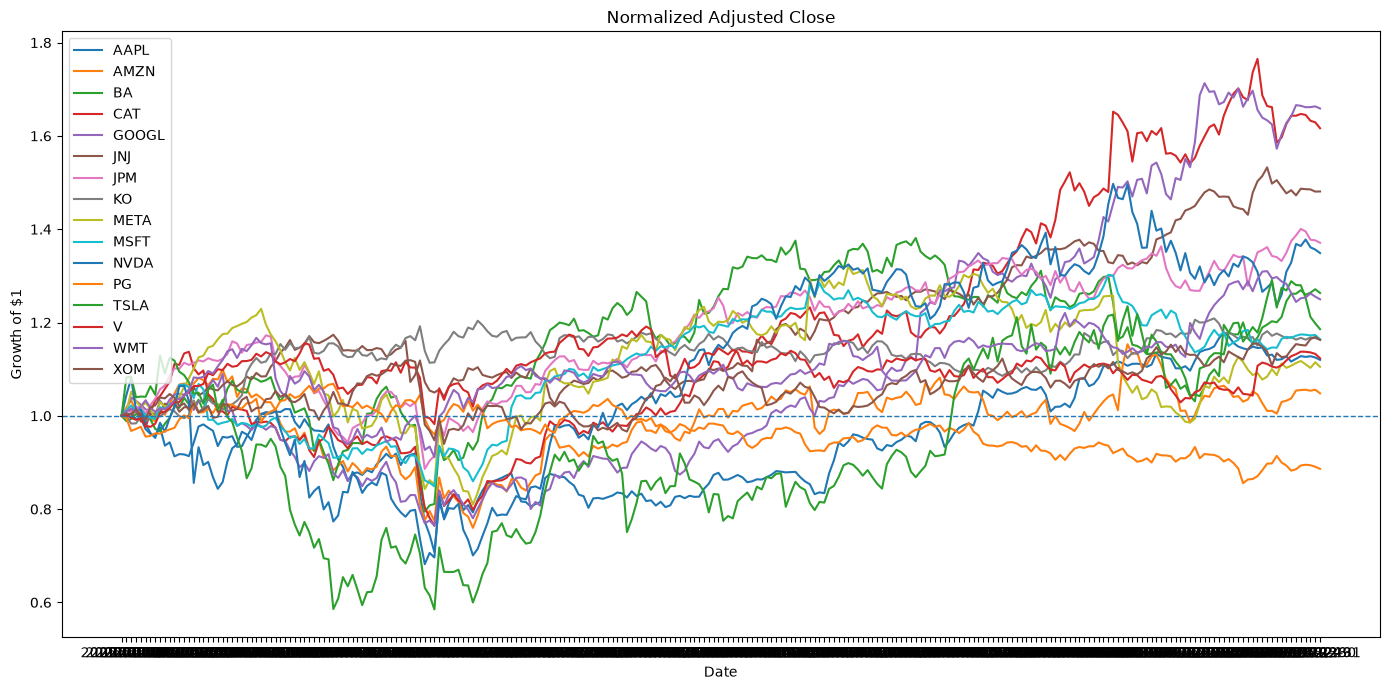

In [35]:
# Normalize returns
start_date = "2025-01-01"
end_date = '2026-01-01'

sorted_data = (
    data[(data['date'] >= start_date) & (data['date'] <= end_date)]
        .sort_values(["ticker", "date"])
        .copy()
)

sorted_data["normalized_close"] = (
    sorted_data.groupby("ticker")["adjusted_close"]
      .transform(lambda x: x / x.iloc[0]) # applies this function to every group, but return one value/row
)

plt.figure(figsize=(14, 7))

for ticker, group in sorted_data.groupby("ticker"):
    plt.plot(group["date"], group["normalized_close"], label=ticker)

plt.axhline(1, linestyle="--", linewidth=1)
plt.title("Normalized Adjusted Close")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.show()

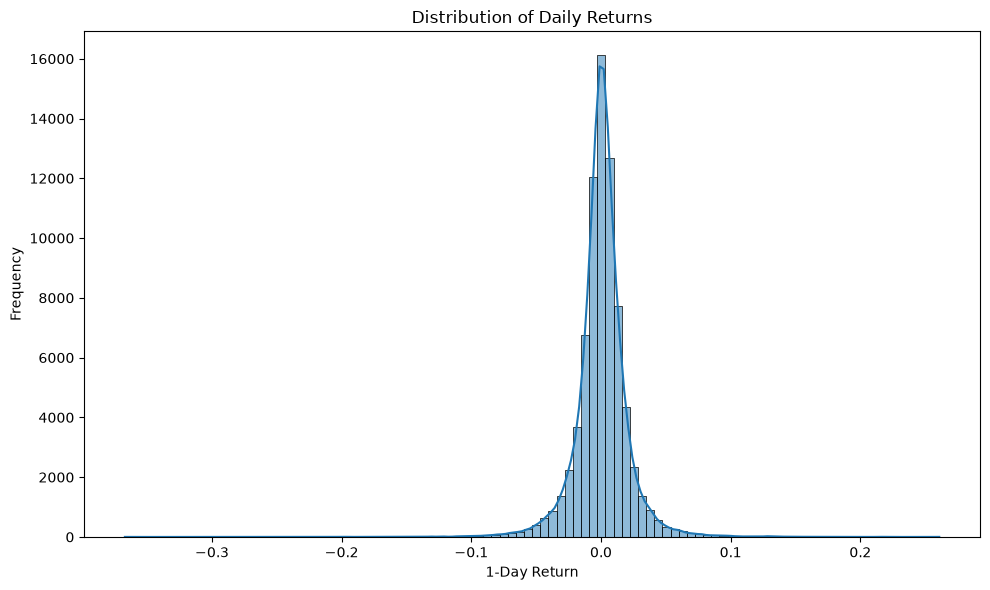

In [36]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="log_return",
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("1-Day Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()